In [2]:
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.prebuilt import ToolNode, tools_condition

In [3]:
def agent_function():
    pass

tools = []

In [4]:
graph_builder=StateGraph(MessagesState)
graph_builder.add_node("agent", agent_function)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge(START,"agent")
graph_builder.add_conditional_edges("agent",tools_condition)
graph_builder.add_edge("tools","agent")
graph_builder.add_edge("agent",END)
graph = graph_builder.compile()

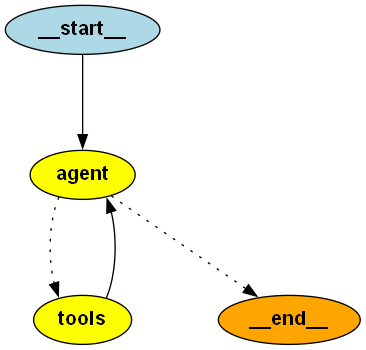

In [5]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [6]:
graph_builder=StateGraph(MessagesState)
graph_builder.add_node("agent", agent_function)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.set_entry_point("agent")
graph_builder.add_conditional_edges("agent",tools_condition) ## tool condition already uses end, so no need to specify end as above
graph_builder.add_edge("tools","agent") # After calling tool go back to agent again



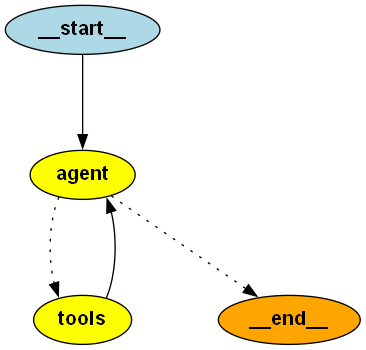

In [7]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [15]:
import serpapi
from dotenv import load_dotenv
import os

_ = load_dotenv()

SERPAPI_API_KEY = os.getenv("SERPAPI_API_KEY")


client = serpapi.Client(api_key=SERPAPI_API_KEY)
results = client.search({
  "engine": "google_flights",
  "departure_id": "CMB",
  "arrival_id": "MAA",
  "currency": "INR",
  "type": "2",
  "outbound_date": "2026-04-05"
})
best_flights = results["best_flights"]

In [16]:
from pprint import pprint

pprint(best_flights, width=120)

[{'airline_logo': 'https://www.gstatic.com/flights/airline_logos/70px/6E.png',
  'booking_token': 'WyJDalJJZFdRMGVtc3RObU5HTVRCQlFubG9ZbWRDUnkwdExTMHRMUzB0TFhaMGFHRXhOVUZCUVVGQlIyNVBXVmRuUzNGeVpEWkJFZ1kyUlRFeE56UWFDZ2lwWXhBQUdnTkpUbEk0SEhEZmFnPT0iLFtbIkNNQiIsIjIwMjYtMDQtMDUiLCJNQUEiLG51bGwsIjZFIiwiMTE3NCJdXV0=',
  'carbon_emissions': {'difference_percent': 2, 'this_flight': 61000, 'typical_for_this_route': 60000},
  'flights': [{'airline': 'IndiGo',
               'airline_logo': 'https://www.gstatic.com/flights/airline_logos/70px/6E.png',
               'airplane': 'Airbus A320neo',
               'arrival_airport': {'id': 'MAA', 'name': 'Chennai International Airport', 'time': '2026-04-05 11:05'},
               'departure_airport': {'id': 'CMB',
                                     'name': 'Colombo Bandaranaike International Airport',
                                     'time': '2026-04-05 09:45'},
               'duration': 80,
               'extensions': ['Below average legroom 

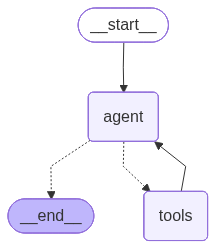

In [11]:
from IPython.display import Image, display

Image(graph.get_graph().draw_mermaid_png())

